We are going to run a very simple model using excel sheet style operations

In [374]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

we will read some data froma  spreadsheet

In [376]:
vehicles = pd.read_csv(r"data\vehicles.csv")
vehicles

,vehicle,power_kwh,fuel
0,tractor,9000,diesel
1,lawnmower,450,petrol
2,generator,1100,petrol
3,generator,2300,diesel


In [375]:
fuel = pd.read_csv(r"data\fuel.csv")
fuel

,fuel,emissions_tons_per_kwh
0,petrol,0.25
1,diesel,0.35


and combine it togheher using a merge

In [377]:
df = fuel.merge(vehicles,"inner","fuel")
df

,fuel,emissions_tons_per_kwh,vehicle,power_kwh
0,petrol,0.25,lawnmower,450
1,petrol,0.25,generator,1100
2,diesel,0.35,tractor,9000
3,diesel,0.35,generator,2300


now we might want to actually define an assumption rather than make data. Set up the window for our model, AKA how many years we want it to run for

In [378]:
years = np.arange(2026,2030,1)
years

array([2026, 2027, 2028, 2029])

then we can define a fucntion that over this window describes a value

In [379]:
def calc_carbon_cost(year):
    cost = 10 + ((year-2026)**0.6)
    return cost

and calculate this (note we are using numpy vectorised aray functions here to do the calculation all at once)

In [380]:
carbon_costs = calc_carbon_cost(years)
carbon_costs

array([10.        , 11.        , 11.51571657, 11.93318204])

quick plot for diagnostics


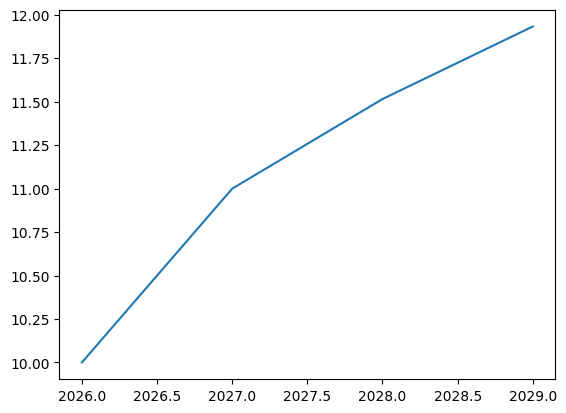

In [381]:
plt.plot(years, carbon_costs)

now we can make a pandas dataframe of this new data too

In [382]:
carbon_costs_table = pd.DataFrame({'year':years, 'offset_base_cost_gbp_per_ton':carbon_costs})
carbon_costs_table

,year,offset_base_cost_gbp_per_ton
0,2026,10.000000
1,2027,11.000000
2,2028,11.515717
3,2029,11.933182


now we have some data, lets merge it all togehter into our main dataframe

In [383]:
df = df.merge(carbon_costs_table,"cross")
df

,fuel,emissions_tons_per_kwh,vehicle,power_kwh,year,offset_base_cost_gbp_per_ton
0,petrol,0.25,lawnmower,450,2026,10.000000
1,petrol,0.25,lawnmower,450,2027,11.000000
2,petrol,0.25,lawnmower,450,2028,11.515717
3,petrol,0.25,lawnmower,450,2029,11.933182
4,petrol,0.25,generator,1100,2026,10.000000
5,petrol,0.25,generator,1100,2027,11.000000
6,petrol,0.25,generator,1100,2028,11.515717
7,petrol,0.25,generator,1100,2029,11.933182
8,diesel,0.35,tractor,9000,2026,10.000000
9,diesel,0.35,tractor,9000,2027,11.000000


You can leave the dataframe as above, but instead for the key rows that we will be indexing by we can tell pandas that this is an index, and that there are non-unique values in these columns that we will want to group by, and it will improve the formatting for us

In [384]:
df = df.set_index(["year", "vehicle", "fuel"]).sort_index()
df

emissions_tons_per_kwh  power_kwh  \
year vehicle   fuel                                        
2026 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2027 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2028 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2029 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   

                       offset_base_cost_gbp_per_ton  
year vehicle   fuel                                  
2026 generator diesel                     10.000000  
               petrol                     10.000000  
     lawnmower petrol                     10.000000  
     tractor   diesel                     10.000000  
2027 generator diesel                     11.000000  
               petrol                     11.000000  
     lawnmower petrol                     11.000000  
     tractor   diesel                     11.000000  
2028 generator diesel                     11.515717  
               petrol                     11.515717  
     lawnmower petrol                     11.515717  
     tractor   diesel                     11.515717  
2029 generator diesel                     11.933182  
               petrol                     11.933182  
     lawnmower petrol                     11.933182  
     tractor   diesel                     11.933182

now we do the calculations we need row by row

In [385]:
df["emissions_tons_per_year"] = df["emissions_tons_per_kwh"] * df["power_kwh"]
df

emissions_tons_per_kwh  power_kwh  \
year vehicle   fuel                                        
2026 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2027 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2028 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2029 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   

                       offset_base_cost_gbp_per_ton  emissions_tons_per_year  
year vehicle   fuel                                                           
2026 generator diesel                     10.000000                    805.0  
               petrol                     10.000000                    275.0  
     lawnmower petrol                     10.000000                    112.5  
     tractor   diesel                     10.000000                   3150.0  
2027 generator diesel                     11.000000                    805.0  
               petrol                     11.000000                    275.0  
     lawnmower petrol                     11.000000                    112.5  
     tractor   diesel                     11.000000                   3150.0  
2028 generator diesel                     11.515717                    805.0  
               petrol                     11.515717                    275.0  
     lawnmower petrol                     11.515717                    112.5  
     tractor   diesel                     11.515717                   3150.0  
2029 generator diesel                     11.933182                    805.0  
               petrol                     11.933182                    275.0  
     lawnmower petrol                     11.933182                    112.5  
     tractor   diesel                     11.933182                   3150.0

In [386]:
df["offset_cost_gbp_per_year"] = df["offset_base_cost_gbp_per_ton"] * df["emissions_tons_per_year"]
df

emissions_tons_per_kwh  power_kwh  \
year vehicle   fuel                                        
2026 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2027 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2028 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2029 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   

                       offset_base_cost_gbp_per_ton  emissions_tons_per_year  \
year vehicle   fuel                                                            
2026 generator diesel                     10.000000                    805.0   
               petrol                     10.000000                    275.0   
     lawnmower petrol                     10.000000                    112.5   
     tractor   diesel                     10.000000                   3150.0   
2027 generator diesel                     11.000000                    805.0   
               petrol                     11.000000                    275.0   
     lawnmower petrol                     11.000000                    112.5   
     tractor   diesel                     11.000000                   3150.0   
2028 generator diesel                     11.515717                    805.0   
               petrol                     11.515717                    275.0   
     lawnmower petrol                     11.515717                    112.5   
     tractor   diesel                     11.515717                   3150.0   
2029 generator diesel                     11.933182                    805.0   
               petrol                     11.933182                    275.0   
     lawnmower petrol                     11.933182                    112.5   
     tractor   diesel                     11.933182                   3150.0   

                       offset_cost_gbp_per_year  
year vehicle   fuel                              
2026 generator diesel               8050.000000  
               petrol               2750.000000  
     lawnmower petrol               1125.000000  
     tractor   diesel              31500.000000  
2027 generator diesel               8855.000000  
               petrol               3025.000000  
     lawnmower petrol               1237.500000  
     tractor   diesel              34650.000000  
2028 generator diesel               9270.151836  
               petrol               3166.822056  
     lawnmower petrol               1295.518114  
     tractor   diesel              36274.507185  
2029 generator diesel               9606.211546  
               petrol               3281.625062  
     lawnmower petrol               1342.482980  
     tractor   diesel              37589.523442

say we want to extract from this the cost over time split per vehicle type. This is summing together the two types of generator. We can do that with a pivot table as in excel

In [387]:
offset_cost_gbp_per_year_by_vehicle = (
    df.pivot_table(
        index="year",
        columns="vehicle",
        values="offset_cost_gbp_per_year",
        aggfunc="sum",
        fill_value=0.0
    )
    .sort_index()
)
offset_cost_gbp_per_year_by_vehicle

vehicle,generator,lawnmower,tractor
year,,,
2026,10800.000000,1125.000000,31500.000000
2027,11880.000000,1237.500000,34650.000000
2028,12436.973892,1295.518114,36274.507185
2029,12887.836609,1342.482980,37589.523442


and then plot

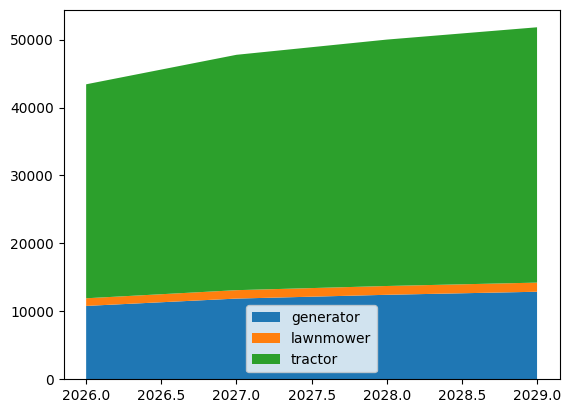

In [388]:
plt.stackplot(offset_cost_gbp_per_year_by_vehicle.index.values,
              offset_cost_gbp_per_year_by_vehicle.values.T,
              labels=offset_cost_gbp_per_year_by_vehicle.columns)
plt.legend()